# Batch Paleomag Data Visualization and Analysis

This notebook loads, parses, and visualizes paleomagnetic data from .hys, .hcr, and .frc files in the LaosBasalts directory. Each section generates a grid of plots for rapid comparison of hysteresis, remanence, and first reversal curve measurements.

## 1. Import Libraries
Import numpy, pandas, matplotlib, and other dependencies for batch paleomag data visualization.

In [5]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 2. Load and Parse Hysteresis (.hys) Data
Recursively search all subfolders for .hys files, parse them, and prepare for plotting.

In [7]:
import os
import glob
import pandas as pd

# Recursively find all .hys files in the LaosBasalts directory and subfolders
hys_dir = '/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data'
hys_files = sorted(glob.glob(os.path.join(hys_dir, '**', '*.hys'), recursive=True))
print(f"Found {len(hys_files)} .hys files.")

Found 26 .hys files.


## 3. Plot Hysteresis Loops (.hys files)
Display a grid of hysteresis loops for all found .hys files (recursively), with 3 columns and as many rows as needed.

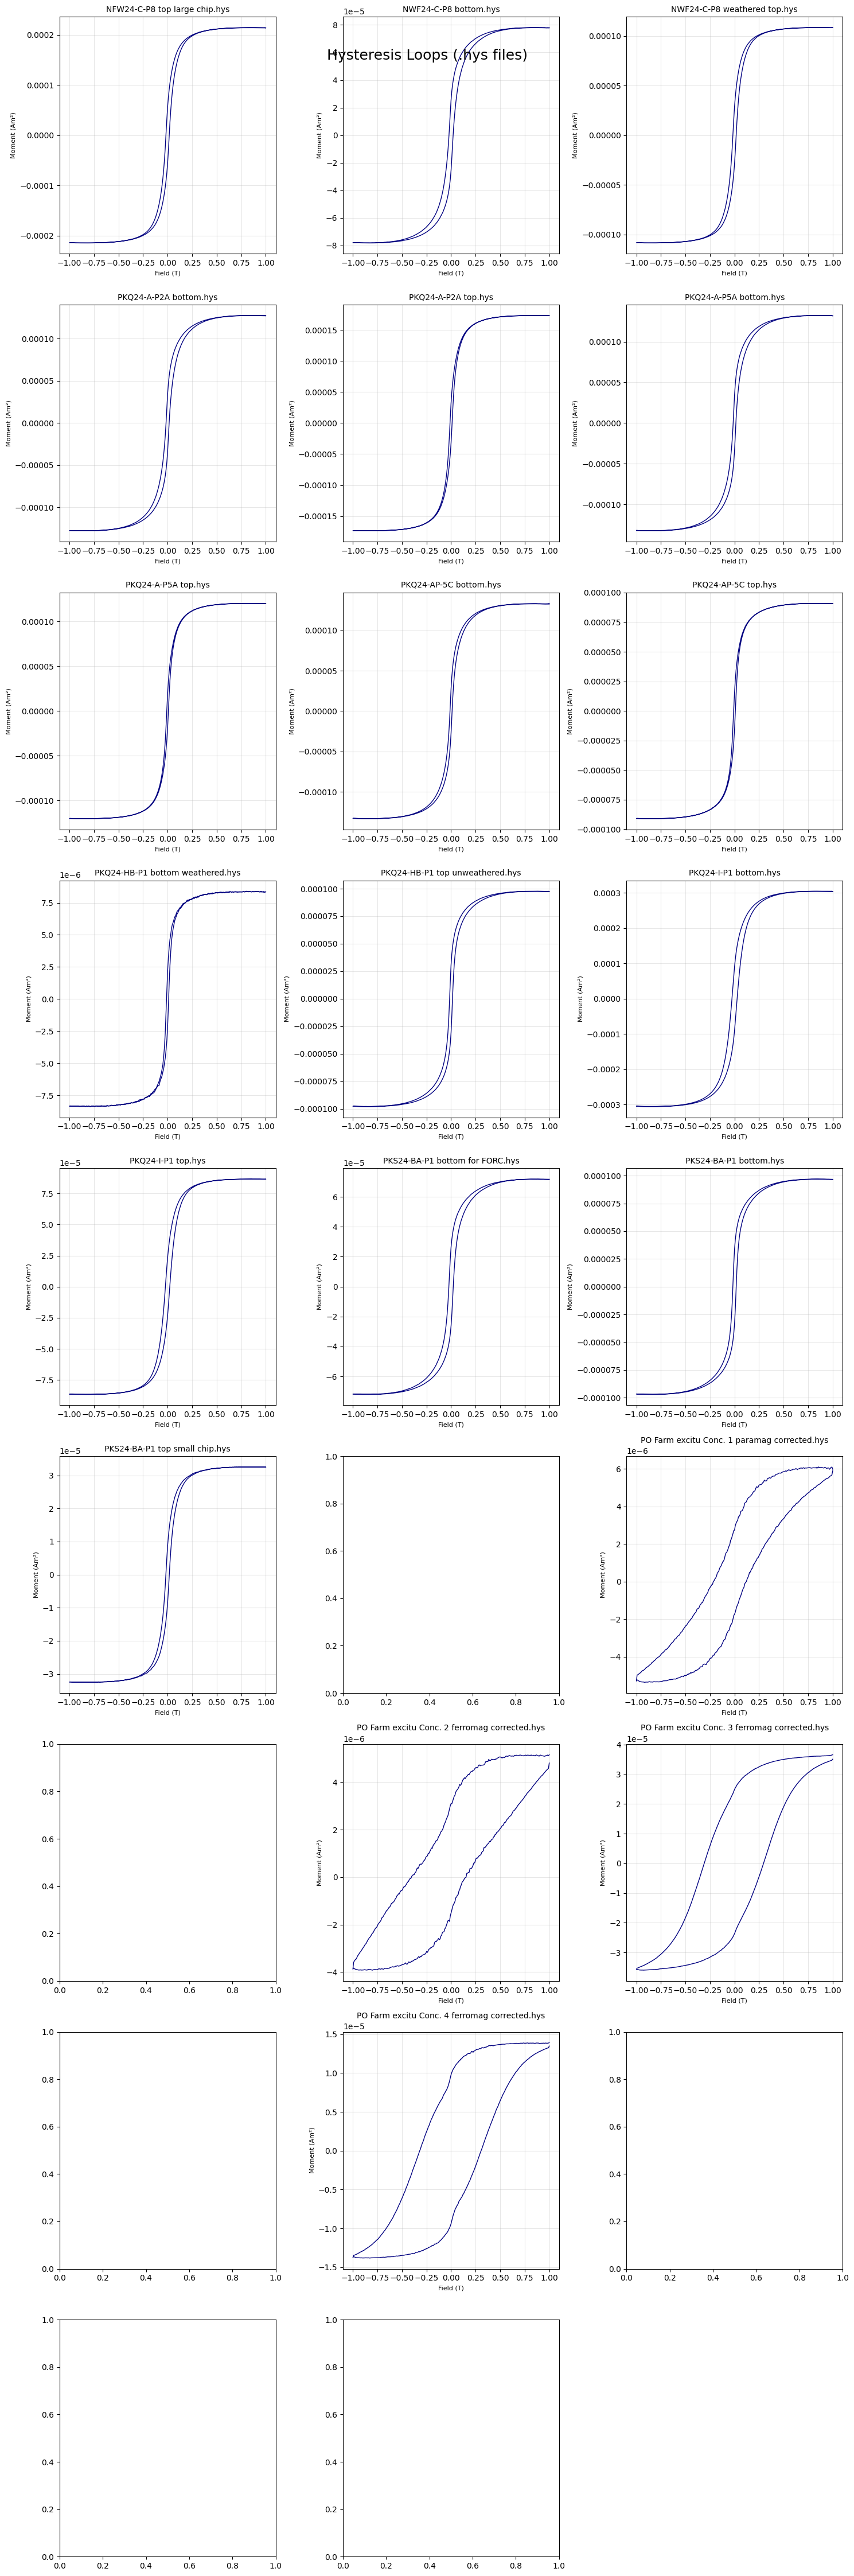

In [ ]:
import matplotlib.pyplot as plt

# Set grid size: always 3 columns, rows depend on file count
n_cols = 3
n_rows = (len(hys_files) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for idx, hys_file in enumerate(hys_files):
    with open(hys_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Adjusted' in line and 'Adjusted' in line:
            data_start = i + 2
            break
    if data_start is None:
        print(f"Warning: Header not found in {hys_file}. Skipping.")
        continue
    data = []
    for line in lines[data_start:]:
        parts = line.strip().split(',')
        if len(parts) == 4:
            try:
                field = float(parts[2])
                moment = float(parts[3])
                data.append([field, moment])
            except ValueError:
                continue
    hys_df = pd.DataFrame(data, columns=['Field_T', 'Moment_Am2']).dropna()
    if hys_df.empty:
        print(f"Warning: No valid data in {hys_file}. Skipping plot.")
        continue
    ax = axes[idx]
    ax.plot(hys_df['Field_T'], hys_df['Moment_Am2'], color='navy', linewidth=1)
    ax.set_title(os.path.basename(hys_file), fontsize=10)
    ax.set_xlabel('Field (T)', fontsize=8)
    ax.set_ylabel('Moment (Am²)', fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[len(hys_files):]:
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Hysteresis Loops (.hys files)', fontsize=18)
plt.show()

## 4. Plot Remanence Curves (.hcr files)
Display a grid of remanence curves for all found .hcr files (recursively), with 3 columns and as many rows as needed.

Found 19 .hcr files.


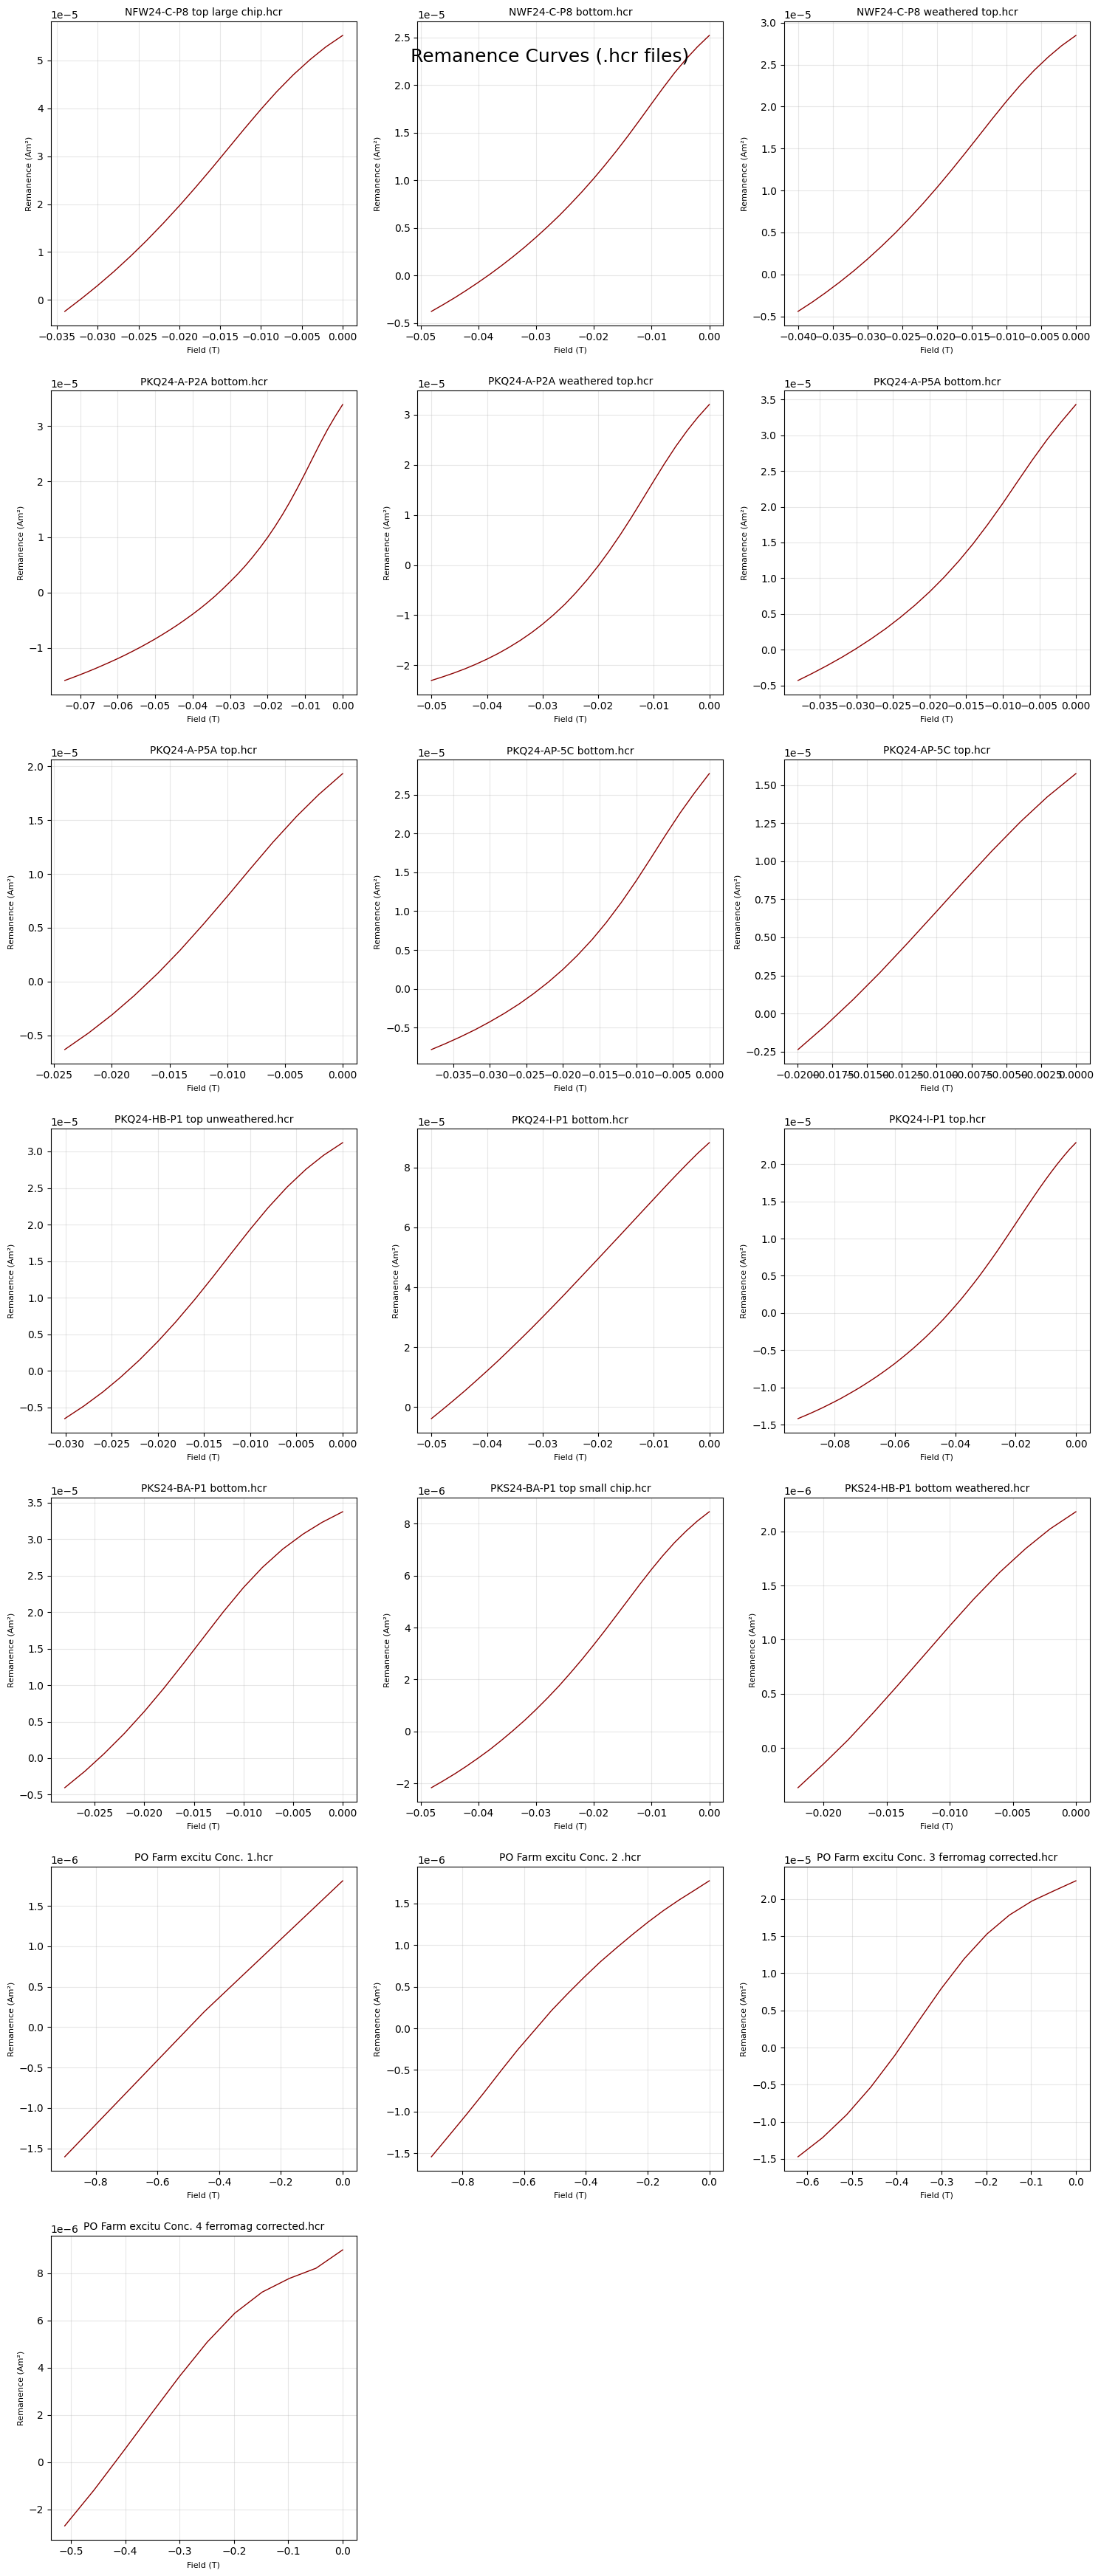

In [ ]:
import re

# Recursively find all .hcr files in the LaosBasalts directory and subfolders
hcr_files = sorted(glob.glob(os.path.join(hys_dir, '**', '*.hcr'), recursive=True))
print(f"Found {len(hcr_files)} .hcr files.")

n_cols = 3
n_rows = (len(hcr_files) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for idx, hcr_file in enumerate(hcr_files):
    with open(hcr_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Field' in line and 'Remanence' in line:
            data_start = i + 1
            break
    if data_start is None:
        print(f"Warning: Header not found in {hcr_file}. Skipping.")
        continue
    data = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line or not re.match(r'[-+0-9Ee.,]+', line):
            continue
        parts = re.split(r'[ ,]+', line)
        if len(parts) >= 2:
            try:
                field = float(parts[0])
                remanence = float(parts[1])
                data.append([field, remanence])
            except ValueError:
                continue
    hcr_df = pd.DataFrame(data, columns=['Field_T', 'Remanence_Am2']).dropna()
    if hcr_df.empty:
        print(f"Warning: No valid data in {hcr_file}. Skipping plot.")
        continue
    ax = axes[idx]
    ax.plot(hcr_df['Field_T'], hcr_df['Remanence_Am2'], color='darkred', linewidth=1)
    ax.set_title(os.path.basename(hcr_file), fontsize=10)
    ax.set_xlabel('Field (T)', fontsize=8)
    ax.set_ylabel('Remanence (Am²)', fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[len(hcr_files):]:
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Remanence Curves (.hcr files)', fontsize=18)
plt.show()

## 5. Plot First Reversal Curves (.frc files)
This section finds all .frc files in the LaosBasalts directory, parses the first reversal curve data, and displays a 3-column by 10-row grid of FRC plots for rapid comparison.

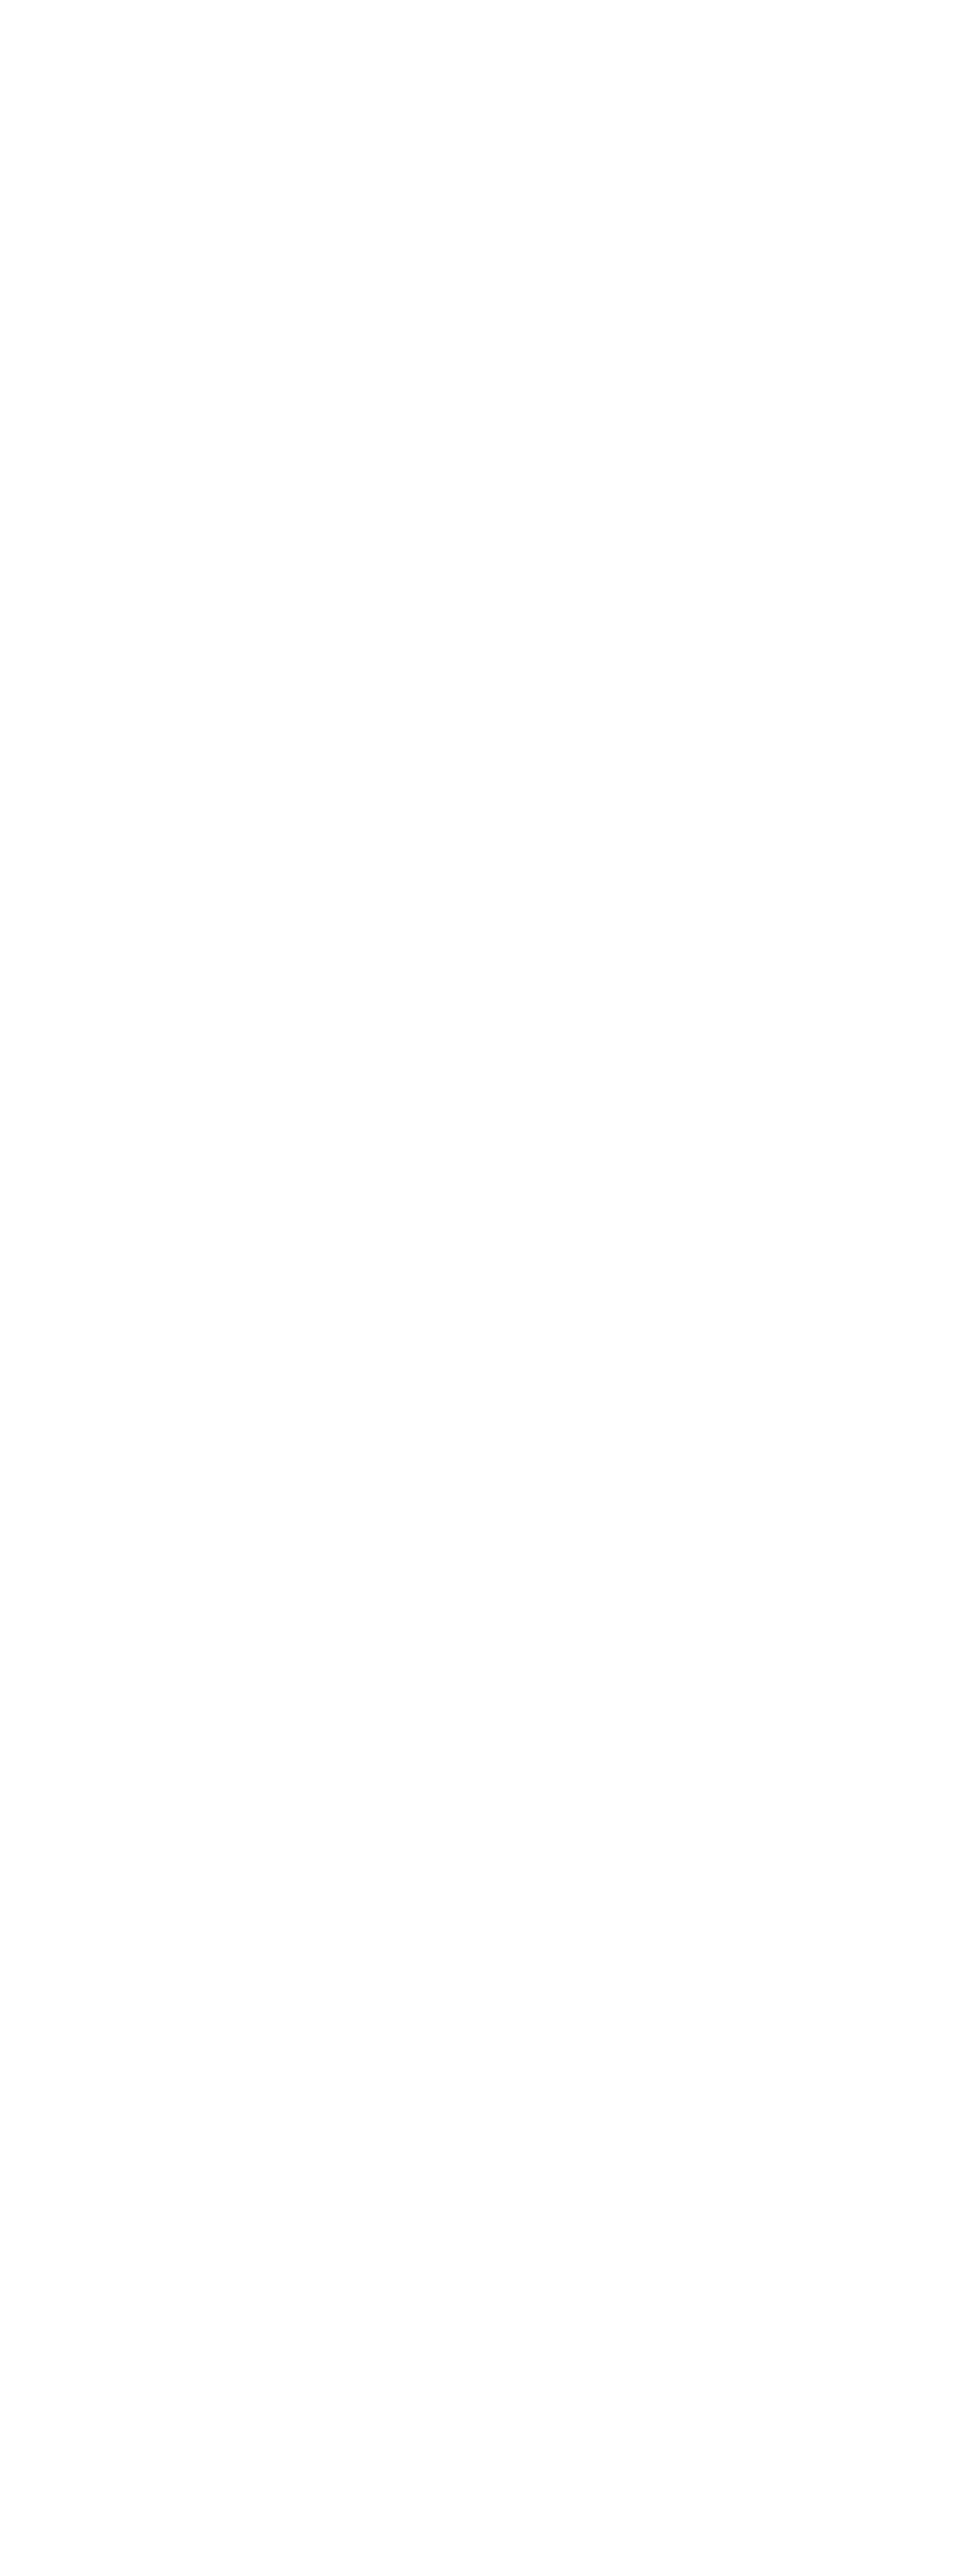

In [ ]:
import re

# Recursively find all .frc files in the LaosBasalts directory and subfolders
frc_files = sorted(glob.glob(os.path.join(hys_dir, '**', '*.frc'), recursive=True))
print(f"Found {len(frc_files)} .frc files.")

n_cols = 3
n_rows = (len(frc_files) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for idx, frc_file in enumerate(frc_files):
    with open(frc_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Field' in line and ('Moment' in line or 'Remanence' in line):
            data_start = i + 1
            break
    if data_start is None:
        print(f"Warning: Header not found in {frc_file}. Skipping.")
        continue
    data = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line or not re.match(r'[-+0-9Ee.,]+', line):
            continue
        parts = re.split(r'[ ,]+', line)
        if len(parts) >= 2:
            try:
                field = float(parts[0])
                remanence = float(parts[1])
                data.append([field, remanence])
            except ValueError:
                continue
    frc_df = pd.DataFrame(data, columns=['Field_T', 'Remanence_Am2']).dropna()
    if frc_df.empty:
        print(f"Warning: No valid data in {frc_file}. Skipping plot.")
        continue
    ax = axes[idx]
    ax.plot(frc_df['Field_T'], frc_df['Remanence_Am2'], color='darkgreen', linewidth=1)
    ax.set_title(os.path.basename(frc_file), fontsize=10)
    ax.set_xlabel('Field (T)', fontsize=8)
    ax.set_ylabel('Remanence (Am²)', fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[len(frc_files):]:
    ax.axis('off')
plt.tight_layout()
plt.suptitle('First Reversal Curves (.frc files)', fontsize=18)
plt.show()

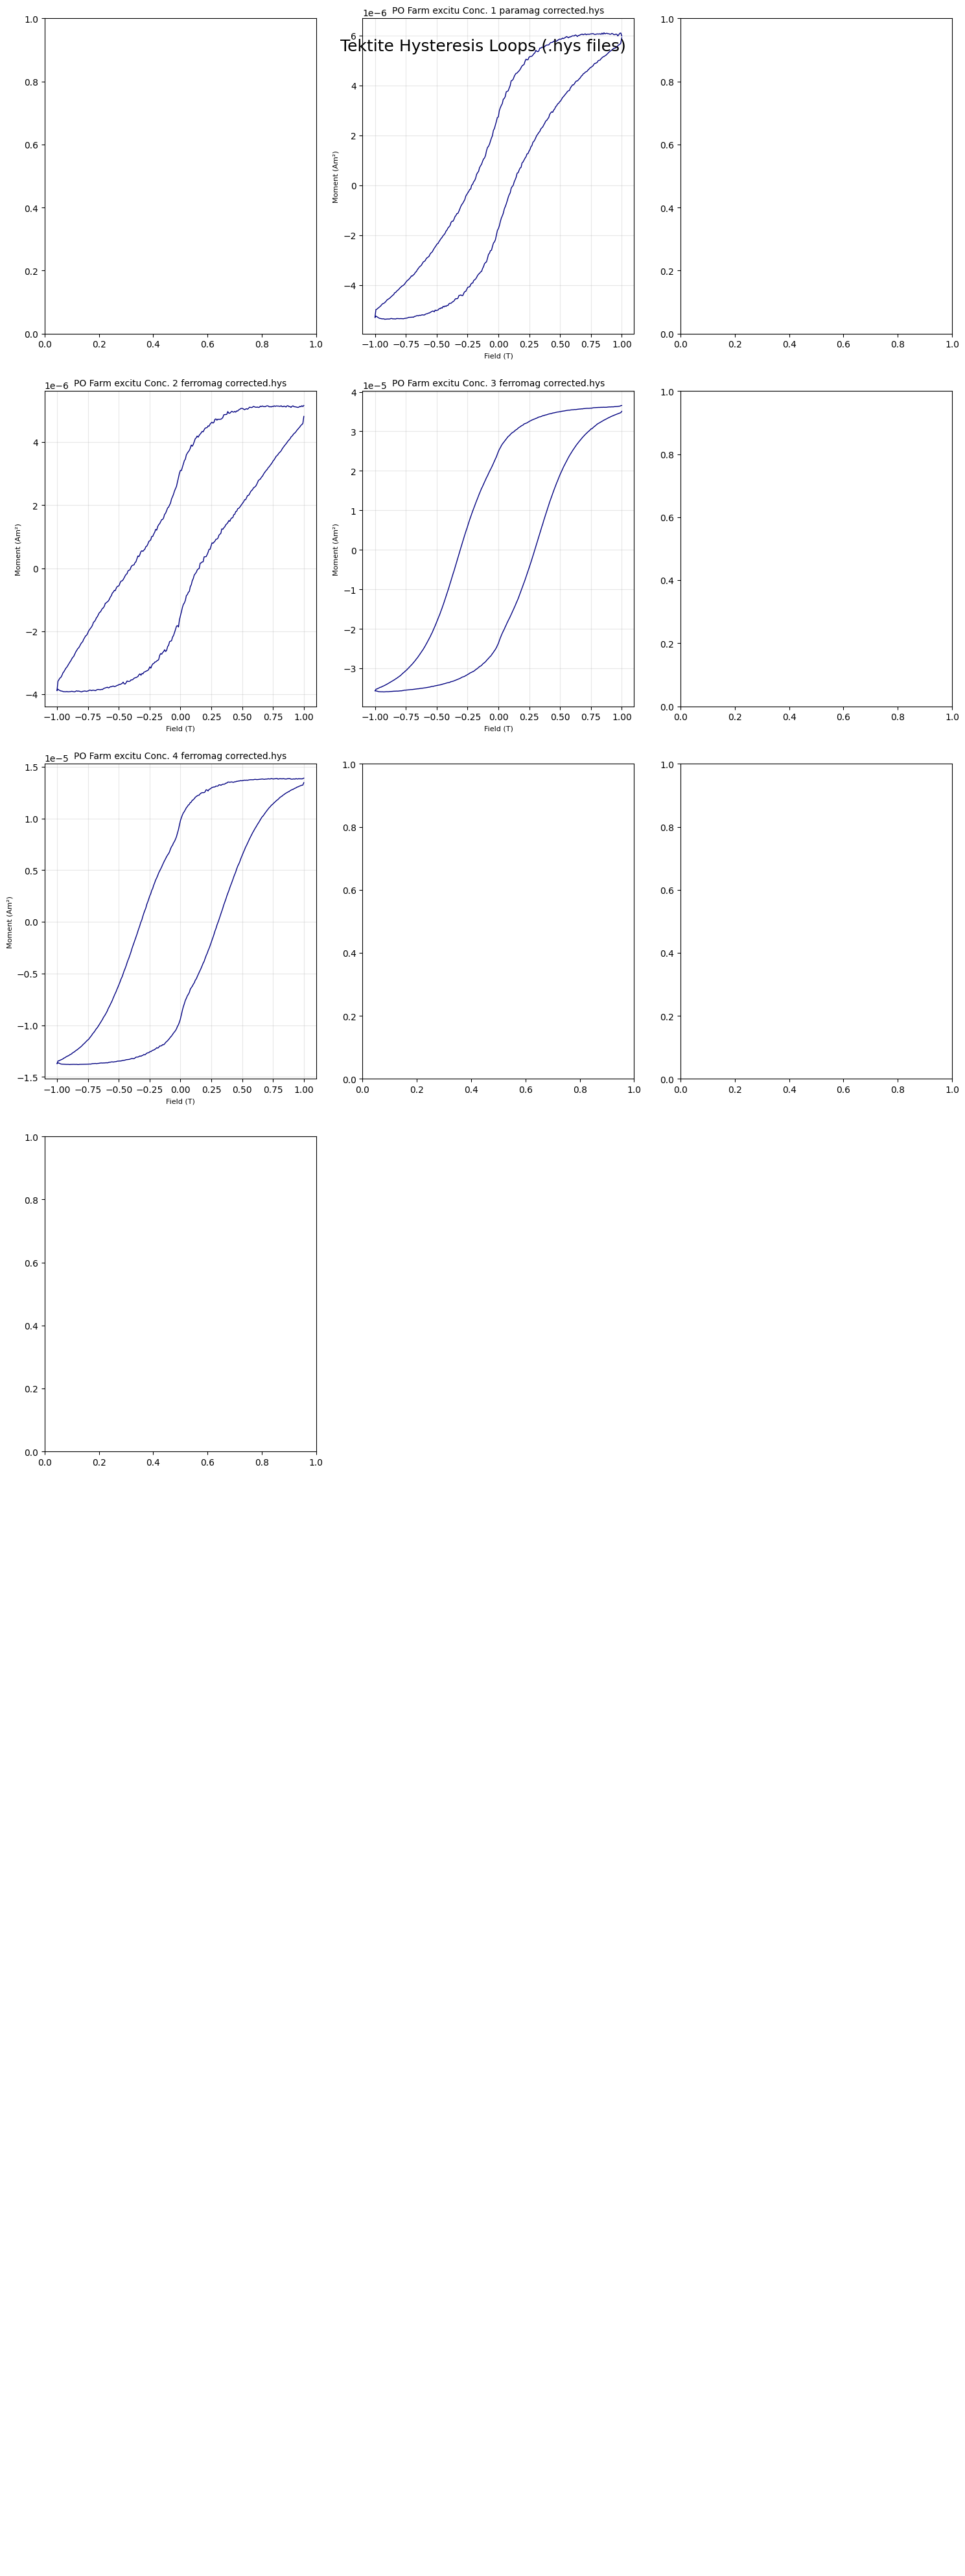

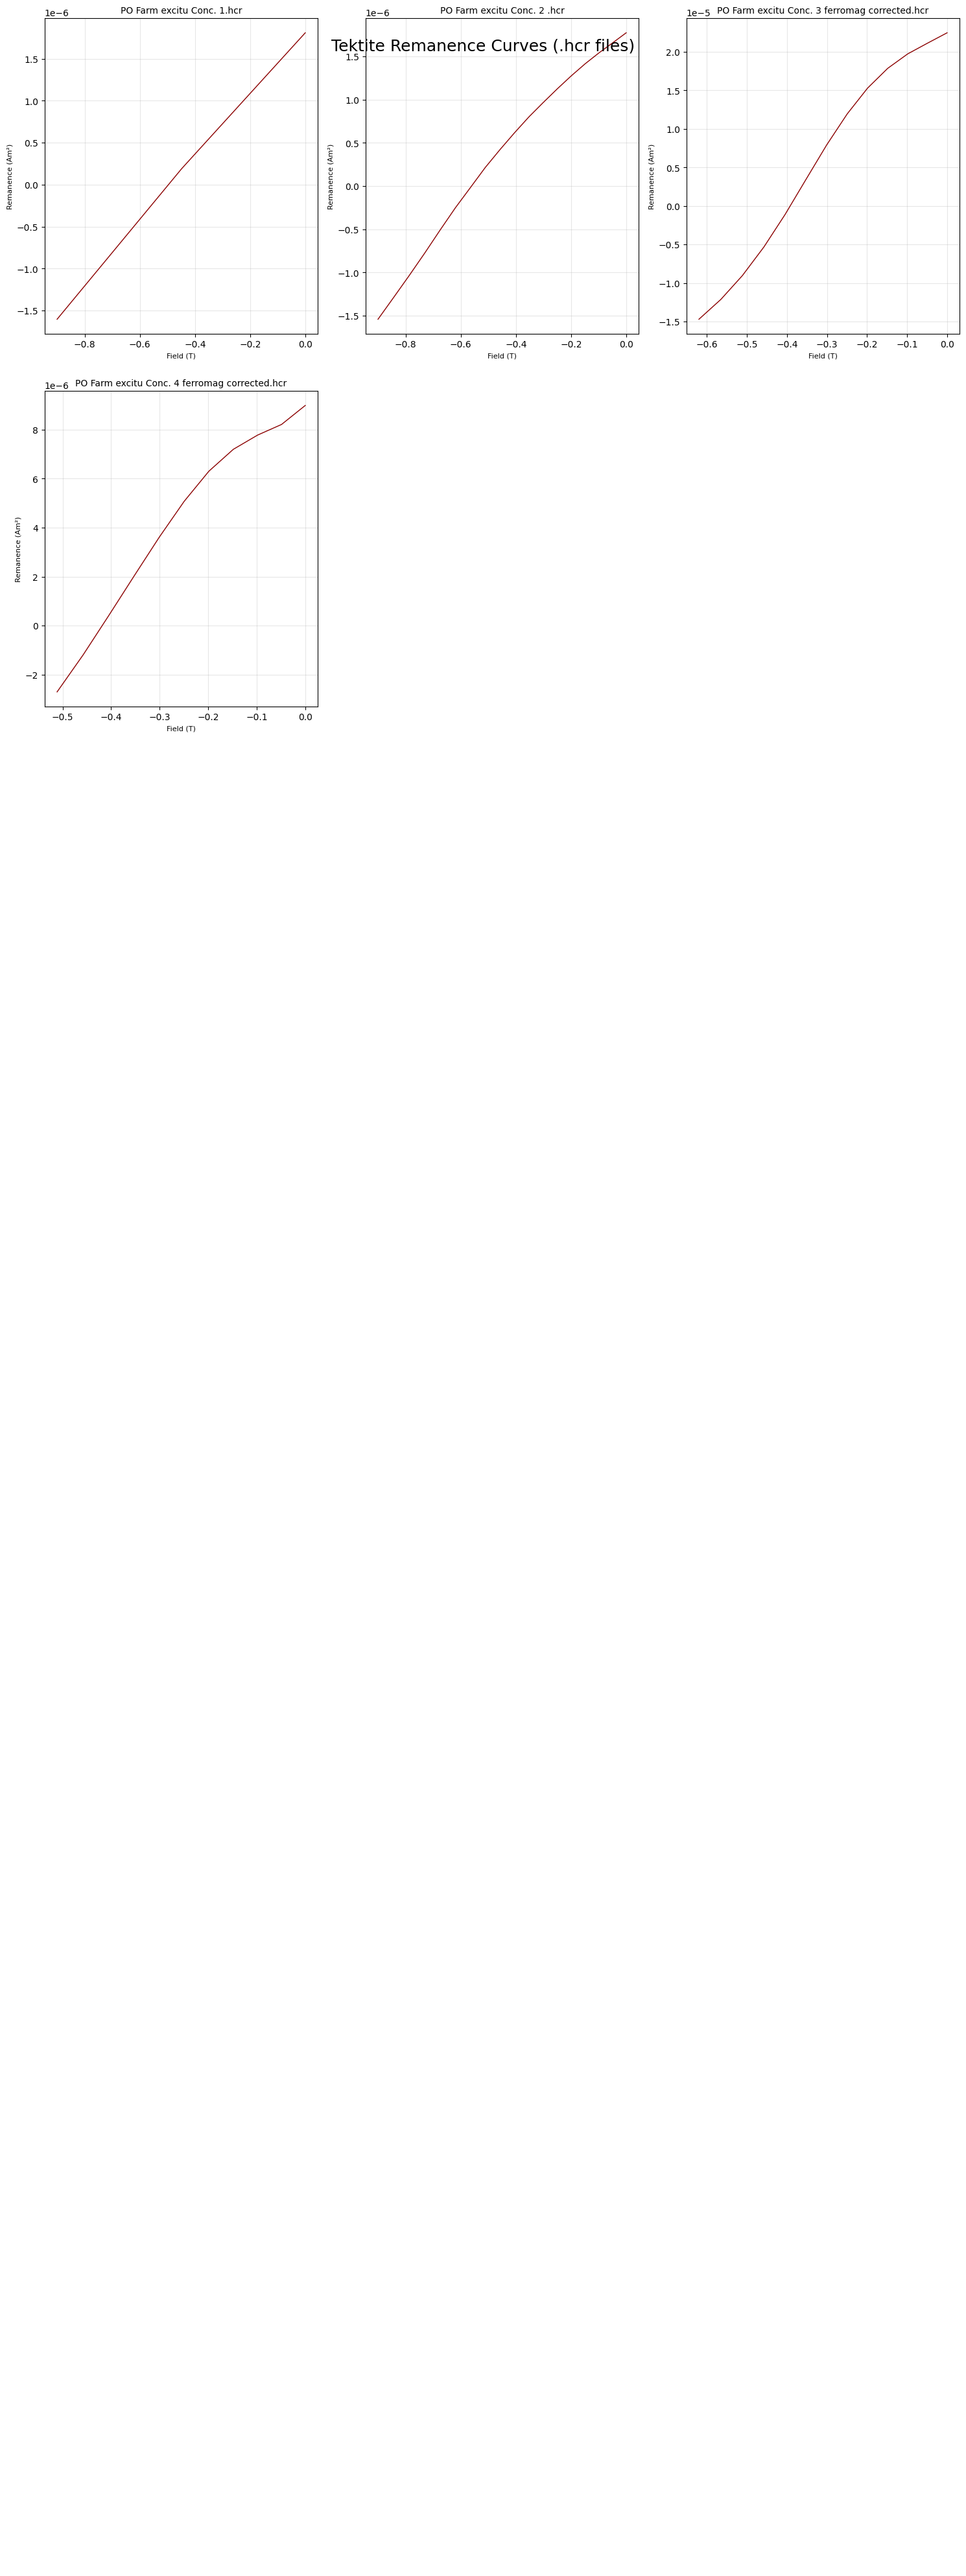

In [3]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# Directory containing Tektite files
tektite_dir = '/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites'

# Find all .hys and .hcr files in the directory
hys_files = sorted(glob.glob(os.path.join(tektite_dir, '*.hys')))
hcr_files = sorted(glob.glob(os.path.join(tektite_dir, '*.hcr')))
n_cols = 3
n_rows = 7

# Plot HYS files
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 40))
axes = axes.flatten()
for idx, hys_file in enumerate(hys_files[:n_cols*n_rows]):
    with open(hys_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Adjusted' in line and 'Adjusted' in line:
            data_start = i + 2
            break
    if data_start is None:
        continue
    data = []
    for line in lines[data_start:]:
        parts = line.strip().split(',')
        if len(parts) == 4:
            try:
                field = float(parts[2])
                moment = float(parts[3])
                data.append([field, moment])
            except ValueError:
                continue
    hys_df = pd.DataFrame(data, columns=['Field_T', 'Moment_Am2']).dropna()
    if hys_df.empty:
        continue
    ax = axes[idx]
    ax.plot(hys_df['Field_T'], hys_df['Moment_Am2'], color='navy', linewidth=1)
    ax.set_title(os.path.basename(hys_file), fontsize=10)
    ax.set_xlabel('Field (T)', fontsize=8)
    ax.set_ylabel('Moment (Am²)', fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[len(hys_files):]:
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Tektite Hysteresis Loops (.hys files)', fontsize=18)
plt.show()

# Plot HCR files
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 40))
axes = axes.flatten()
for idx, hcr_file in enumerate(hcr_files[:n_cols*n_rows]):
    with open(hcr_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Field' in line and 'Remanence' in line:
            data_start = i + 1
            break
    if data_start is None:
        continue
    data = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line or not re.match(r'[-+0-9Ee.,]+', line):
            continue
        parts = re.split(r'[ ,]+', line)
        if len(parts) >= 2:
            try:
                field = float(parts[0])
                remanence = float(parts[1])
                data.append([field, remanence])
            except ValueError:
                continue
    hcr_df = pd.DataFrame(data, columns=['Field_T', 'Remanence_Am2']).dropna()
    if hcr_df.empty:
        continue
    ax = axes[idx]
    ax.plot(hcr_df['Field_T'], hcr_df['Remanence_Am2'], color='darkred', linewidth=1)
    ax.set_title(os.path.basename(hcr_file), fontsize=10)
    ax.set_xlabel('Field (T)', fontsize=8)
    ax.set_ylabel('Remanence (Am²)', fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[len(hcr_files):]:
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Tektite Remanence Curves (.hcr files)', fontsize=18)
plt.show()